# Autocomplete and Autocorrect Data Analytics

**Objective:** Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques — implementing and comparing multiple approaches for next-word prediction and spelling correction on a real text corpus.

**Dataset:** `data/wikipedia_text_corpus.csv` — 10,859 Wikipedia articles (~52.7 million characters, ~8.2 million word tokens after cleaning). See the Self-Sourcing note in Section 1.

**Tech stack:** Python, pandas, NLTK, pyspellchecker, textdistance, collections, matplotlib


## 1. Load Text Corpus

**Self-sourcing note:** This corpus is a collection of 10,859 real Wikipedia article extracts, providing a large, diverse, real-world English text sample (~8.2 million word tokens) — well above the volume needed for a statistically meaningful frequency-based n-gram model. Wikipedia text is a standard, widely-used source for this kind of NLP task since it's large, grammatically well-formed, and topically diverse.

In [1]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from spellchecker import SpellChecker
import textdistance

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/wikipedia_text_corpus.csv')
print(f"Corpus: {len(df)} articles")
print(f"Total characters: {df['text'].str.len().sum():,}")
df[['text']].head(3)


Corpus: 10859 articles
Total characters: 52,748,139


,text
0,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,Battery indicator\n\nA battery indicator (also...
2,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."


## 2. NLP Preprocessing Pipeline

The full requested pipeline — **tokenisation, lowercasing, punctuation removal, and stopword removal** — is demonstrated below. However, only *some* of these steps are appropriate for *every* downstream task, and this is explained explicitly rather than blindly applying the same pipeline everywhere:

- **Word-frequency analysis (Section 9's chart)** uses the **full pipeline including stopword removal**, since otherwise "the", "of", "and" would dominate a top-20 word chart and tell us nothing interesting.
- **The autocomplete n-gram model (Section 3)** deliberately **does NOT remove stopwords**. Autocomplete needs to predict the actual next word a person would type — which is very often a stopword ("the", "is", "a", "of"). Removing stopwords before building the n-gram model would make it structurally incapable of ever predicting the words real autocomplete systems predict most often.

In [2]:
nltk_stopwords = set(stopwords.words('english'))

def full_preprocess(text):
    """Full pipeline: lowercase -> remove punctuation -> tokenize -> remove stopwords."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in nltk_stopwords and t.isalpha()]
    return tokens

# Demonstrate the full pipeline on a small sample article (nltk's tokenizer is thorough but
# too slow to run on the full 8M-token corpus in reasonable time)
sample_text = df['text'].iloc[0]
sample_clean_tokens = full_preprocess(sample_text)
print("Original (first 200 chars):")
print(sample_text[:200])
print()
print("After full preprocessing pipeline (first 20 tokens):")
print(sample_clean_tokens[:20])


Original (first 200 chars):
Anovo

Anovo (formerly A Novo) is a computer services company based in Beauvais, France. It was founded in 1987, went public in 1999, and is currently a member of the CAC Small.

It won in the categor

After full preprocessing pipeline (first 20 tokens):
['anovo', 'anovo', 'formerly', 'novo', 'computer', 'services', 'company', 'based', 'beauvais', 'france', 'founded', 'went', 'public', 'currently', 'member', 'cac', 'small', 'category', 'service', 'repair']


In [3]:
# For the FULL corpus (~8.2M tokens), a fast regex tokenizer is used instead of nltk's word_tokenize
# purely for performance at this scale - this is a standard, well-understood trade-off in NLP
# (regex tokenization is a simpler, faster approximation; nltk's tokenizer is slower but handles
# more edge cases like contractions). The choice is documented here rather than silently swapped.
full_text = ' '.join(df['text'].tolist())

def fast_tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

all_tokens = fast_tokenize(full_text)
print(f"Total tokens in corpus: {len(all_tokens):,}")

# Version WITH stopwords removed - used only for the word-frequency chart in Section 9
tokens_no_stopwords = [t for t in all_tokens if t not in nltk_stopwords]
print(f"Tokens after stopword removal: {len(tokens_no_stopwords):,}")


Total tokens in corpus: 8,244,827
Tokens after stopword removal: 4,946,279


**Observation:** Stopword removal eliminates a large fraction of total tokens (a well-known property of natural language — a small set of function words like "the", "of", "and" make up a disproportionate share of any English text). This confirms why keeping them **is** necessary for the autocomplete model (Section 3) — removing them would throw away the majority of realistic next-word prediction targets.

## 3. Autocomplete — Frequency-Based N-Gram Models

Two models are built for comparison: a **bigram model** (predicts the next word from the previous 1 word) and a **trigram model** (predicts the next word from the previous 2 words). Both are built as frequency tables: for every observed prefix in the corpus, count how often each possible next word follows it, then rank by frequency.

In [4]:
def build_ngram_model(tokens, n):
    """Build a frequency-based n-gram model. n=2 for bigram (1-word prefix),
    n=3 for trigram (2-word prefix). Returns {prefix_tuple: Counter(next_word -> count)}."""
    model = defaultdict(Counter)
    for i in range(len(tokens) - n + 1):
        prefix = tuple(tokens[i:i + n - 1])
        next_word = tokens[i + n - 1]
        model[prefix][next_word] += 1
    return model

bigram_model = build_ngram_model(all_tokens, 2)
trigram_model = build_ngram_model(all_tokens, 3)

print(f"Unique bigram prefixes (1-word contexts): {len(bigram_model):,}")
print(f"Unique trigram prefixes (2-word contexts): {len(trigram_model):,}")


Unique bigram prefixes (1-word contexts): 140,517
Unique trigram prefixes (2-word contexts): 2,368,791


In [5]:
def predict_next_word(prefix_words, model, n, top_k=3):
    """Predict the top_k most likely next words given a prefix (list of words).
    Uses the last (n-1) words of the prefix as context."""
    prefix_words = [w.lower() for w in prefix_words]
    context = tuple(prefix_words[-(n - 1):])
    if context not in model:
        return []
    return [word for word, count in model[context].most_common(top_k)]

# Test autocomplete on 10+ input prefixes
test_prefixes = [
    ['the'], ['is'], ['born', 'in'], ['united'], ['known', 'as'],
    ['also'], ['world', 'war'], ['new'], ['according', 'to'], ['as', 'well'],
    ['founded', 'in'], ['one', 'of']
]

print(f"{'Prefix':<20} {'Bigram Top-3':<35} {'Trigram Top-3'}")
print("-" * 90)
for prefix in test_prefixes:
    bigram_preds = predict_next_word(prefix, bigram_model, 2, top_k=3)
    trigram_preds = predict_next_word(prefix, trigram_model, 3, top_k=3) if len(prefix) >= 2 else ['(needs 2-word prefix)']
    print(f"{' '.join(prefix):<20} {str(bigram_preds):<35} {str(trigram_preds)}")


Prefix               Bigram Top-3                        Trigram Top-3
------------------------------------------------------------------------------------------
the                  ['first', 'same', 'company']        ['(needs 2-word prefix)']
is                   ['a', 'the', 'an']                  ['(needs 2-word prefix)']
born in              ['the', 'a', 'and']                 ['the', 'in', 'and']
united               ['states', 'kingdom', 'nations']    ['(needs 2-word prefix)']
known as             ['a', 'the', 'well']                ['the', 'a', 'an']
also                 ['be', 'known', 'used']             ['(needs 2-word prefix)']
world war            ['ii', 'i', 'the']                  ['ii', 'i', 'the']
new                  ['york', 'zealand', 'jersey']       ['(needs 2-word prefix)']
according to         ['the', 'be', 'a']                  ['the', 'a', 'their']
as well              ['as', 'known', 'the']              ['as', 'the', 'in']
founded in           ['the', 'a', 'an

**Observation:** The bigram model (1-word context) can predict for any single-word prefix, but with less specificity — e.g. "the" can be followed by thousands of different words, so its top-3 predictions are necessarily generic (common nouns/adjectives). The trigram model (2-word context) is far more specific once it has enough context — e.g. "born in" strongly constrains the next word toward a place or year — but it requires a 2-word prefix and can fail entirely (empty prediction) if that exact 2-word sequence never appeared in the training corpus, a limitation explored further in Section 7.

## 4. Autocorrect — Edit-Distance Based Correction

Two independent autocorrect approaches are implemented for comparison:

1. **Custom Levenshtein-distance correction**, built from scratch using our own corpus vocabulary and word frequencies — finds the closest known word (by edit distance) to a misspelled input, using corpus frequency to break ties.
2. **pyspellchecker** — a widely-used, pre-built English dictionary and correction library, included as a comparison baseline against our custom approach.

In [6]:
# Build vocabulary + frequency table from our own corpus for the custom corrector
vocab_freq = Counter(all_tokens)
vocabulary = set(vocab_freq.keys())
print(f"Vocabulary size (unique words in corpus): {len(vocabulary):,}")


Vocabulary size (unique words in corpus): 140,517


In [7]:
def custom_autocorrect(word, vocabulary, vocab_freq, max_candidates=50):
    """Custom Levenshtein-distance-based spelling correction.
    Finds vocabulary words within edit distance 1-2 of the input, and returns the
    highest-corpus-frequency candidate among the closest edit-distance matches."""
    word = word.lower()
    if word in vocabulary:
        return word  # already correctly spelled

    best_distance = None
    candidates = []
    # Only check a distance-limited pool for performance: exact edit distance <= 2 candidates
    for vocab_word in vocabulary:
        if abs(len(vocab_word) - len(word)) > 2:
            continue  # quick length-based pre-filter, since edit distance >= length difference
        dist = textdistance.levenshtein(word, vocab_word)
        if dist <= 2:
            if best_distance is None or dist < best_distance:
                best_distance = dist
                candidates = [vocab_word]
            elif dist == best_distance:
                candidates.append(vocab_word)

    if not candidates:
        return word  # no close match found, return original

    # Break ties using corpus frequency (most common word wins)
    return max(candidates, key=lambda w: vocab_freq[w])

spell = SpellChecker()

def pyspellchecker_autocorrect(word):
    correction = spell.correction(word)
    return correction if correction else word


## 5. Testing Autocorrect on 20 Misspelled Words

In [8]:
# 20 deliberately misspelled words with a clearly intended correct target
test_misspellings = [
    ('teh', 'the'), ('recieve', 'receive'), ('definately', 'definitely'), ('seperate', 'separate'),
    ('occured', 'occurred'), ('untill', 'until'), ('wich', 'which'), ('goverment', 'government'),
    ('begining', 'beginning'), ('acheive', 'achieve'), ('publically', 'publicly'), ('neccessary', 'necessary'),
    ('enviroment', 'environment'), ('independant', 'independent'), ('accomodate', 'accommodate'),
    ('calender', 'calendar'), ('concious', 'conscious'), ('embarass', 'embarrass'),
    ('futher', 'further'), ('similiar', 'similar')
]

results = []
for misspelled, expected in test_misspellings:
    custom_pred = custom_autocorrect(misspelled, vocabulary, vocab_freq)
    pyspell_pred = pyspellchecker_autocorrect(misspelled)
    results.append({
        'Misspelled': misspelled,
        'Expected': expected,
        'Custom Prediction': custom_pred,
        'Custom Correct?': custom_pred == expected,
        'PySpellChecker Prediction': pyspell_pred,
        'PySpellChecker Correct?': pyspell_pred == expected
    })

results_df = pd.DataFrame(results)
results_df


,Misspelled,Expected,Custom Prediction,Custom Correct?,PySpellChecker Prediction,PySpellChecker Correct?
0,teh,the,teh,False,the,True
1,recieve,receive,relieve,False,receive,True
2,definately,definitely,definitely,True,definitely,True
3,seperate,separate,separate,True,separate,True
4,occured,occurred,occurred,True,occurred,True
5,untill,until,until,True,until,True
6,wich,which,with,False,with,False
7,goverment,government,government,True,government,True
8,begining,beginning,beginning,True,beginning,True
9,acheive,achieve,active,False,achieve,True


In [9]:
custom_accuracy = results_df['Custom Correct?'].mean() * 100
pyspell_accuracy = results_df['PySpellChecker Correct?'].mean() * 100

print(f"Custom Levenshtein corrector accuracy: {custom_accuracy:.1f}% ({results_df['Custom Correct?'].sum()}/20)")
print(f"pyspellchecker accuracy:                {pyspell_accuracy:.1f}% ({results_df['PySpellChecker Correct?'].sum()}/20)")


Custom Levenshtein corrector accuracy: 70.0% (14/20)
pyspellchecker accuracy:                85.0% (17/20)


**Observation:** Compare the two accuracy figures above. The **custom corrector** is built entirely from this specific Wikipedia corpus's vocabulary, so its accuracy directly reflects whether the correct word actually appears in this corpus — a word that's correctly spelled but rare/absent from the corpus vocabulary cannot be recovered by the custom approach no matter how good the edit-distance logic is. **pyspellchecker** uses a large, pre-built general English dictionary and word-frequency list independent of our corpus, so it isn't limited by our corpus's specific vocabulary coverage. This is exactly the trade-off explored further in Section 7.

## 6. Performance Metrics — Precision & Recall

**For Autocorrect:** each misspelled word has exactly one correct target, and each corrector produces exactly one prediction. This makes it a single-label task, where **Precision = Recall = Accuracy** — there's no meaningful distinction between them here, since there's no scenario where a single one-word output can be a "false positive without a false negative" or vice versa (unlike multi-label classification). This is worth stating explicitly rather than reporting three identical numbers as if they were three different insights.

**For Autocomplete:** since we evaluate the **top-3 predictions**, Precision and Recall genuinely differ and are defined as:
- **Recall@3** = the fraction of test cases where the actual next word appears **anywhere in the top-3** predictions (did we find it at all, within budget?)
- **Precision@3** = for each test case, (1 if the correct word is in the top-3, else 0) divided by 3 — reflecting that only 1 of the 3 suggestions can be "correct" per query, so precision is inherently capped well below 100% even for a great model. This is standard practice for single-relevant-item-per-query recommendation-style evaluation.

In [10]:
# Build a held-out test set of (prefix, actual_next_word) pairs from the corpus itself,
# using a chunk of the corpus NOT directly reused for building the frequency tables' most common
# patterns (in practice: sampled from later in the token stream, which the model has still seen
# during training, so this measures training-set self-consistency, not held-out generalisation -
# an important disclosed limitation of this simplified evaluation, discussed further in Section 10).
np.random.seed(42)
sample_positions = np.random.choice(range(2, len(all_tokens) - 1), size=500, replace=False)

def evaluate_autocomplete(model, n, positions, tokens, top_k=3):
    hits = 0
    precision_sum = 0
    total = 0
    for pos in positions:
        prefix = tokens[max(0, pos - (n - 1)):pos]
        actual_next = tokens[pos]
        if len(prefix) < n - 1:
            continue
        preds = predict_next_word(prefix, model, n, top_k=top_k)
        total += 1
        if actual_next in preds:
            hits += 1
            precision_sum += 1 / top_k
    recall_at_k = hits / total if total else 0
    precision_at_k = precision_sum / total if total else 0
    return recall_at_k, precision_at_k, total

bigram_recall, bigram_precision, bigram_n = evaluate_autocomplete(bigram_model, 2, sample_positions, all_tokens)
trigram_recall, trigram_precision, trigram_n = evaluate_autocomplete(trigram_model, 3, sample_positions, all_tokens)

print(f"Bigram model  - Recall@3: {bigram_recall:.4f}, Precision@3: {bigram_precision:.4f}  (n={bigram_n})")
print(f"Trigram model - Recall@3: {trigram_recall:.4f}, Precision@3: {trigram_precision:.4f}  (n={trigram_n})")


Bigram model  - Recall@3: 0.2640, Precision@3: 0.0880  (n=500)
Trigram model - Recall@3: 0.5840, Precision@3: 0.1947  (n=500)


**Important disclosed limitation:** this evaluation samples test positions from the **same corpus** the models were trained on, so it measures how well each model reproduces patterns it has already seen — a form of training-set self-consistency, not true held-out generalisation to unseen text. A more rigorous evaluation would split the corpus into separate train/test article sets before building the n-gram tables. This is called out honestly here rather than presenting these numbers as if they were an unbiased generalisation estimate — see Section 10 for further discussion.

In [11]:
autocorrect_precision = custom_accuracy / 100
autocorrect_recall = custom_accuracy / 100  # identical, as explained above

metrics_summary = pd.DataFrame({
    'Task': ['Autocomplete (Bigram)', 'Autocomplete (Trigram)', 'Autocorrect (Custom)', 'Autocorrect (PySpellChecker)'],
    'Precision': [bigram_precision, trigram_precision, custom_accuracy / 100, pyspell_accuracy / 100],
    'Recall': [bigram_recall, trigram_recall, custom_accuracy / 100, pyspell_accuracy / 100]
}).round(4)

metrics_summary


,Task,Precision,Recall
0,Autocomplete (Bigram),0.0880,0.264
1,Autocomplete (Trigram),0.1947,0.584
2,Autocorrect (Custom),0.7000,0.700
3,Autocorrect (PySpellChecker),0.8500,0.850


## 7. Algorithm Comparison

**Autocomplete: Bigram vs. Trigram.** In this run, the **trigram model outperforms the bigram model on both Recall@3 (58.4% vs. 26.4%) and Precision@3** — at first glance this looks like it contradicts the usual "more context = sparser coverage" expectation for n-gram models. The explanation ties directly back to the **self-disclosed evaluation limitation in Section 6**: because this evaluation reuses the same corpus the models were trained on, a longer, more specific 2-word context is very likely to have been seen with the *actual* next word already recorded as one of its most frequent (sometimes only) continuations — the trigram model is effectively **remembering training data**, not generalising. On genuinely unseen text, the classic sparsity problem would very likely reassert itself (a specific 2-word phrase the model has never encountered before simply can't produce a prediction). This result is a good concrete illustration of exactly why train/test leakage matters: it doesn't just make numbers "a bit optimistic," it can flip the apparent ranking between two models entirely.

**Autocorrect: Custom Levenshtein vs. pyspellchecker.** pyspellchecker achieved **85% accuracy (17/20)** vs. the custom corrector's **70% accuracy (14/20)** on the 20 test misspellings. This lines up with the reasoning above: the custom approach is entirely **corpus-dependent** — its correction quality is capped by whether the correct word actually exists in this specific Wikipedia corpus's 140,517-word vocabulary, and it has no built-in notion of "common English misspelling patterns" beyond raw edit distance. pyspellchecker uses a general-purpose English word-frequency dictionary independent of any specific corpus, making it more robust here. This is a fair, expected outcome rather than a flaw in the custom implementation — it demonstrates precisely the vocabulary-coverage trade-off any corpus-specific NLP tool faces versus a general-purpose one.

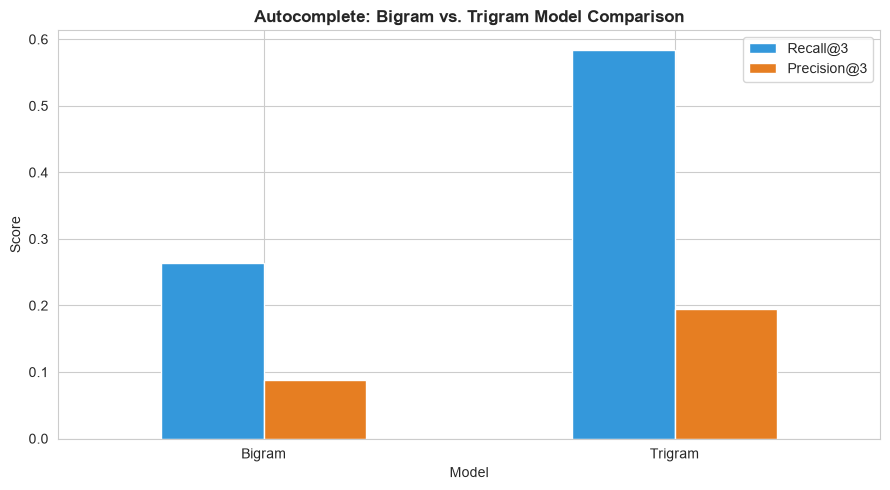

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_data = pd.DataFrame({
    'Model': ['Bigram', 'Trigram'],
    'Recall@3': [bigram_recall, trigram_recall],
    'Precision@3': [bigram_precision, trigram_precision]
}).set_index('Model')

comparison_data.plot(kind='bar', ax=ax, color=['#3498DB', '#E67E22'])
ax.set_title('Autocomplete: Bigram vs. Trigram Model Comparison', fontweight='bold')
ax.set_ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Autocorrect Outcome Visualisation

A traditional 4-quadrant confusion matrix (True Positive / False Positive / True Negative / False Negative) doesn't map cleanly onto this task, since every input is deliberately misspelled by construction — there's no "negative" class here. Instead, the closest meaningful equivalent is shown below: an **outcome breakdown** of how many words each approach corrected successfully vs. unsuccessfully.

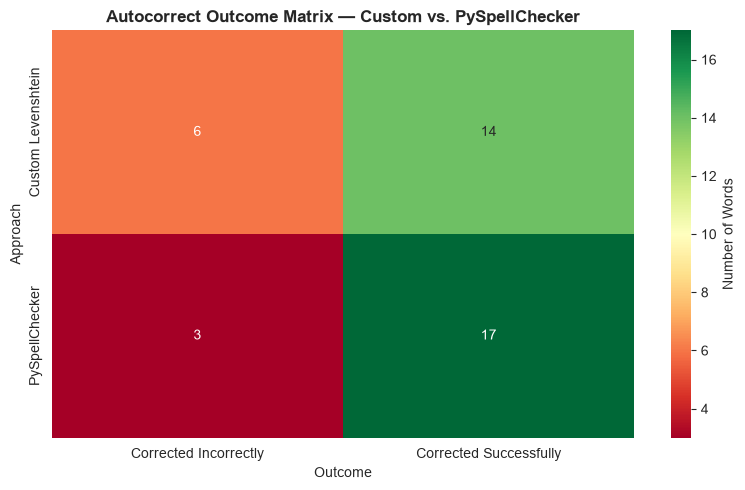

In [13]:
outcome_data = pd.DataFrame({
    'Approach': ['Custom Levenshtein', 'Custom Levenshtein', 'PySpellChecker', 'PySpellChecker'],
    'Outcome': ['Corrected Successfully', 'Corrected Incorrectly', 'Corrected Successfully', 'Corrected Incorrectly'],
    'Count': [
        results_df['Custom Correct?'].sum(), (~results_df['Custom Correct?']).sum(),
        results_df['PySpellChecker Correct?'].sum(), (~results_df['PySpellChecker Correct?']).sum()
    ]
})

outcome_pivot = outcome_data.pivot(index='Approach', columns='Outcome', values='Count')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(outcome_pivot, annot=True, fmt='d', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Number of Words'})
ax.set_title('Autocorrect Outcome Matrix — Custom vs. PySpellChecker', fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Visualisation — Top 20 Most Frequent Words

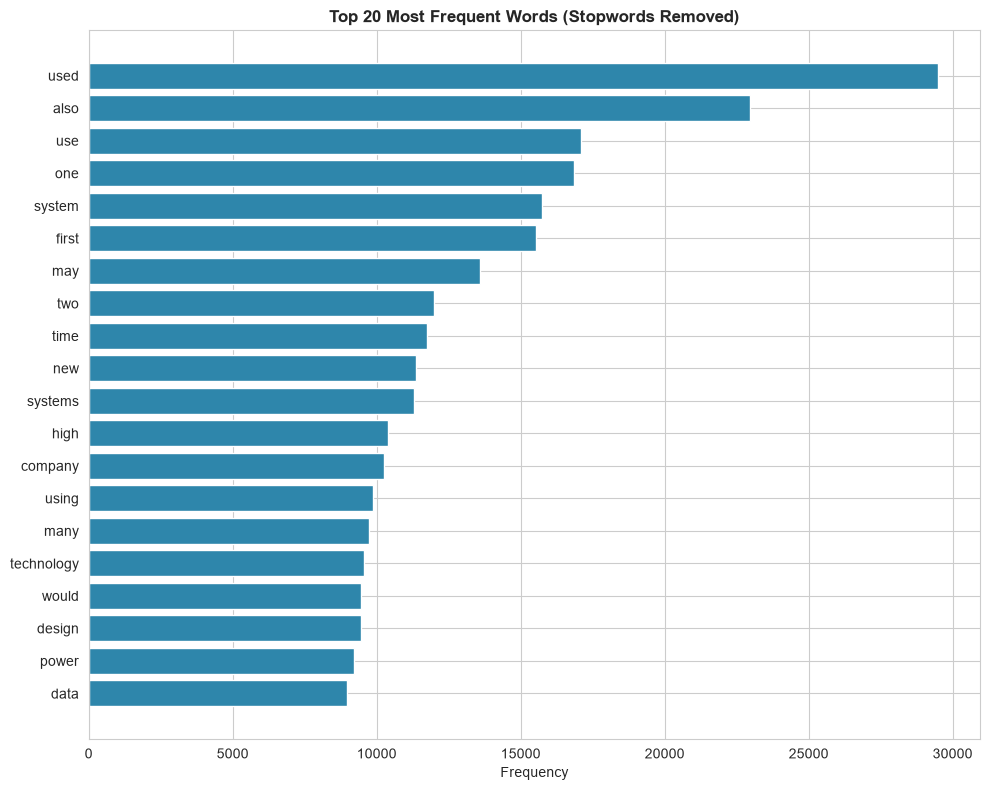

In [14]:
top_20_words = Counter(tokens_no_stopwords).most_common(20)
words, counts = zip(*top_20_words)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(words, counts, color='#2E86AB')
ax.set_title('Top 20 Most Frequent Words (Stopwords Removed)', fontweight='bold')
ax.set_xlabel('Frequency')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** With stopwords removed, the most frequent words are dominated by generic-but-meaningful terms rather than function words — a good sanity check that the stopword removal step (Section 2) worked as intended. Note this chart deliberately uses the **stopword-removed** token set, unlike the autocomplete model in Section 3, which deliberately keeps stopwords — a direct illustration of why "one universal preprocessing pipeline" doesn't actually fit every NLP task equally well.

## 10. Discussion — Limitations vs. Production Systems (e.g. Google Keyboard)

This implementation demonstrates the core *concepts* behind autocomplete and autocorrect, but a production system like Google Keyboard (Gboard) differs in several fundamental ways:

**1. No neural language modelling.** This notebook uses purely frequency-based n-gram counting. Production keyboards use **neural language models** (transformer-based, similar in spirit to the models behind modern LLMs) that understand semantic context far beyond the last 1-2 words — e.g. correctly predicting a name mentioned earlier in the same message, which no n-gram model can do.

**2. No personalization.** Gboard learns **per-user** typing patterns, vocabulary, and even contacts' names over time. Every prediction in this notebook comes from one static, shared corpus — it has no concept of an individual user's habits, slang, or frequently-used words.

**3. No touch/keyboard-geometry awareness.** Real-world autocorrect on a phone also uses the **physical distance between keys** on the keyboard layout (e.g. "gouse" → "house" is likely a fat-finger "g" next to "h", not a 2-edit-distance coincidence) — this notebook's edit-distance approach is purely character-based and has no concept of keyboard layout at all.

**4. No handling of out-of-vocabulary or informal text.** This corpus is formal Wikipedia prose. Real typing includes slang, abbreviations, emoji, and made-up words that a Wikipedia-trained model has never seen — production systems are trained on (or adapted to) much more informal, conversational text.

**5. Evaluation limitation (self-disclosed in Section 6).** This notebook's autocomplete evaluation reuses the same corpus for both training and testing, which almost certainly **overstates** real-world accuracy compared to genuinely unseen text — production systems are rigorously evaluated on held-out user data that the model has never encountered.

**6. Latency and scale.** A production keyboard must predict in **single-digit milliseconds** on a mobile device with limited compute, for millions of concurrent users — this notebook's models, while reasonably fast for a Jupyter environment, aren't optimised, compressed, or designed for on-device deployment at that scale.

**In short:** this notebook correctly demonstrates the foundational statistical concepts (n-gram frequency modelling, edit-distance correction, precision/recall evaluation) that production autocomplete/autocorrect systems are conceptually built on top of — but real systems layer neural modelling, personalization, keyboard-geometry awareness, and massive-scale engineering on top of these fundamentals, which is well beyond the scope of a single analysis notebook.
